In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
import sklearn.metrics as metrics
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import optuna
import shap

In [2]:
df_ablat_raw = pd.read_csv('data/input_df_SUMMmet_ablat.csv')

sites_to_drop = ['PTSH', 'SPST', 'SR01', 'SR25', 'SR11']
df_ablat = df_ablat_raw[~df_ablat_raw['site.x'].isin(sites_to_drop)]

df_ablat = df_ablat[df_ablat['delta'] > -30]
df_ablat = df_ablat[df_ablat['delta'] < 28]

df_ablat = df_ablat.drop(['ant1d_SNOD', 'SNOD', 'date', 'X', 'Unnamed: 0', 'site.x', 'day', 'site.y'], axis = 1)


In [3]:
X_ablat = df_ablat.drop('delta', axis = 1)
y_ablat = df_ablat['delta']

X_column_names = X_ablat.columns
y_column_names = y_ablat.name

scaler_X_ablat = StandardScaler()
X_ablat_fit = pd.DataFrame(scaler_X_ablat.fit_transform(X_ablat))
X_ablat_fit.columns = X_column_names

y_ablat_values = pd.DataFrame(y_ablat).values

scaler_y_ablat = StandardScaler()
y_ablat_fit = pd.Series(scaler_y_ablat.fit_transform(y_ablat_values)[:,0])
y_ablat_fit.name = y_column_names

In [4]:
X_ablat_fit_train, X_ablat_fit_test, y_ablat_fit_train, y_ablat_fit_test = train_test_split(X_ablat_fit, 
                                                                                            y_ablat_fit, 
                                                                                            test_size=0.2, 
                                                                                            random_state=11)

In [5]:
ablat_backprop = MLPRegressor(hidden_layer_sizes = [50],
                              activation = 'logistic',
                              learning_rate_init = 0.0008365271891069903,
                              alpha = 0.002801061505975249,
                              max_iter = 2000,
                              shuffle = False,
                              random_state = 42,
                              tol = 1.8211893449697042e-06,
                              n_iter_no_change=100,
                              verbose = True,
                              learning_rate='adaptive',
                              solver = 'adam')

ablat_backprop.fit(X_ablat_fit_train, y_ablat_fit_train)
preds_ablat = ablat_backprop.predict(X_ablat_fit_test)

preds_ablat = scaler_y_ablat.inverse_transform(preds_ablat.reshape(-1,1))
y_ablat_test_2 = scaler_y_ablat.inverse_transform(np.array(y_ablat_fit_test).reshape(-1,1))

rmse_ablat = metrics.root_mean_squared_error(y_ablat_test_2, preds_ablat)
r2_ablat = metrics.r2_score(y_ablat_test_2, preds_ablat)



Iteration 1, loss = 0.48858046
Iteration 2, loss = 0.46443633
Iteration 3, loss = 0.44949393
Iteration 4, loss = 0.43687389
Iteration 5, loss = 0.42548598
Iteration 6, loss = 0.41634782
Iteration 7, loss = 0.40907992
Iteration 8, loss = 0.40284179
Iteration 9, loss = 0.39743319
Iteration 10, loss = 0.39274567
Iteration 11, loss = 0.38848972
Iteration 12, loss = 0.38450266
Iteration 13, loss = 0.38074184
Iteration 14, loss = 0.37715145
Iteration 15, loss = 0.37369676
Iteration 16, loss = 0.37037192
Iteration 17, loss = 0.36716597
Iteration 18, loss = 0.36407084
Iteration 19, loss = 0.36108612
Iteration 20, loss = 0.35820982
Iteration 21, loss = 0.35543840
Iteration 22, loss = 0.35276815
Iteration 23, loss = 0.35019475
Iteration 24, loss = 0.34771475
Iteration 25, loss = 0.34532548
Iteration 26, loss = 0.34302397
Iteration 27, loss = 0.34080660
Iteration 28, loss = 0.33866936
Iteration 29, loss = 0.33660834
Iteration 30, loss = 0.33462023
Iteration 31, loss = 0.33270218
Iteration 32, los

c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


rmse =  3.2933919684792228
r2 =  0.3373762364764913


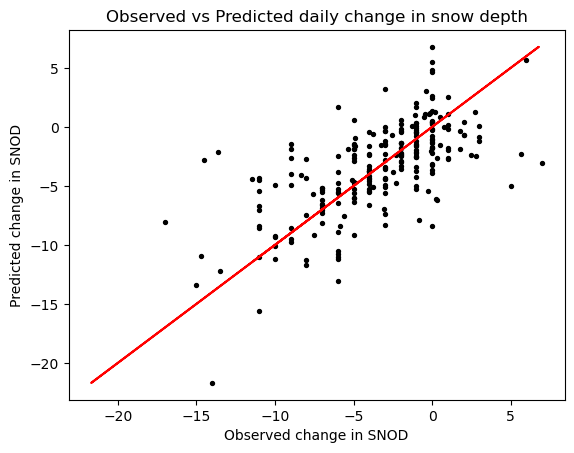

In [6]:
plt.scatter(y_ablat_test_2, preds_ablat, s = 8, c = "black")
plt.plot(preds_ablat, preds_ablat, c = "red")
plt.xlabel("Observed change in SNOD")
plt.ylabel("Predicted change in SNOD")
plt.title("Observed vs Predicted daily change in snow depth")
print("rmse = ", rmse_ablat) 
print("r2 = ", r2_ablat)

rmse =  0.9633589202980805
r2 =  0.9361679655311572


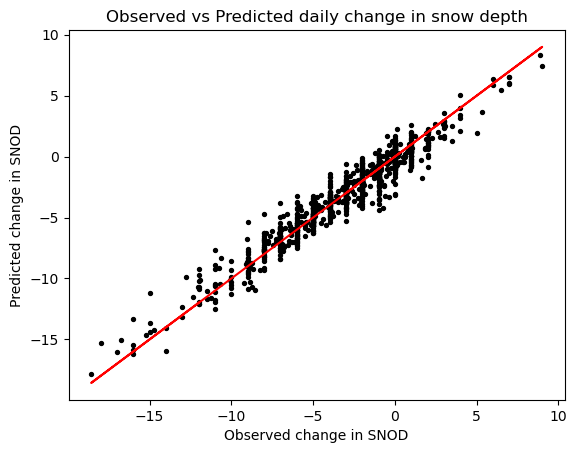

In [17]:
preds_ablat_train = ablat_backprop.predict(X_ablat_fit_train)

preds_ablat_train = scaler_y_ablat.inverse_transform(preds_ablat_train.reshape(-1,1))
y_ablat_train_1 = scaler_y_ablat.inverse_transform(np.array(y_ablat_fit_train).reshape(-1,1))

rmse_ablat_train = metrics.root_mean_squared_error(y_ablat_train_1, preds_ablat_train)
r2_ablat_train = metrics.r2_score(y_ablat_train_1, preds_ablat_train)

plt.scatter(y_ablat_train_1, preds_ablat_train, s = 8, c = "black")
plt.plot(y_ablat_train_1, y_ablat_train_1, c = "red")
plt.xlabel("Observed change in SNOD")
plt.ylabel("Predicted change in SNOD")
plt.title("Observed vs Predicted daily change in snow depth")
print("rmse = ", rmse_ablat_train) 
print("r2 = ", r2_ablat_train)

In [5]:
def objective(trial):
        # Suggest hyperparameters for MLP
    hidden_layer_sizes = trial.suggest_categorical('hidden_layer_sizes', [(50), (100),(200), (100,100), (200,200)])
    alpha = trial.suggest_float('alpha', 1e-8, 1e-2, log = True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-8, 1e-2, log = True)
    tolerance = trial.suggest_float('tolerance', 1e-8, 1e-2, log = True)
    n_iter_no_change = trial.suggest_int('n_iter_no_change', 10, 200)

    kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
    fold_accuracies = []

    for train_index, val_index in kf.split(X_ablat_fit):

        X_train = X_ablat_fit.iloc[train_index]
        X_val = X_ablat_fit.iloc[val_index]
        y_train = y_ablat_fit[train_index]
        y_val = y_ablat_fit[val_index]        

        # Create MLP model with suggested hyperparameters
        model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes,
                            activation='logistic',
                            solver='adam',
                            alpha=alpha,
                            learning_rate_init=learning_rate_init,
                            tol = tolerance,
                            n_iter_no_change = n_iter_no_change,
                            max_iter=2000, # Set a reasonable max_iter
                            random_state=42)

        # Train the model
        model.fit(X_train, y_train)

        # Evaluate the model
        preds_ablat = model.predict(X_val)
        preds_ablat = scaler_y_ablat.inverse_transform(preds_ablat.reshape(-1,1))
        y_ablat_test_2 = scaler_y_ablat.inverse_transform(np.array(y_val).reshape(-1,1))

        score = metrics.root_mean_squared_error(y_ablat_test_2, preds_ablat)
        fold_accuracies.append(score)

    return sum(fold_accuracies)/len(fold_accuracies) 

study = optuna.create_study(direction='minimize') # 'minimize' for error, 'maximize' for accuracy/score
study.optimize(objective, n_trials=100) # Run 50 trials

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_params}")


[I 2025-11-25 20:32:32,456] A new study created in memory with name: no-name-6be33d7f-afdf-4edb-8773-f1710eb35b16
c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 100) which is of type tuple.
  warnings.warn(message)
c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (200, 200) which is of type tuple.
  warnings.warn(message)
[I 2025-11-25 20:32:36,940] Trial 0 finished with value: 4.159779837017172 and parameters: {'hidden_layer_sizes': 100, 'alpha': 1.1322783441372927e-07, 'learning_rate_init': 2.5820138811619863e-08, 'tolerance': 0.00017620985349767063, 'n_iter_no_change': 124}. Best is trial 0 with value: 4.159779837017172.
c:

Best trial: 2.620849791431115
Best hyperparameters: {'hidden_layer_sizes': 200, 'alpha': 0.009389831969734239, 'learning_rate_init': 0.0006725303113609219, 'tolerance': 4.727571983243658e-08, 'n_iter_no_change': 182}


In [18]:
explainer = shap.Explainer(ablat_backprop.predict, X_ablat_fit_train)
#shap_values_train = explainer.shap_values(X_ablat_fit_train)
#shap_values_test = explainer.shap_values(X_ablat_fit_test)
shap_values_full = explainer.shap_values(X_ablat_fit)

PermutationExplainer explainer: 1220it [00:30, 32.85it/s]                          


In [19]:
shap_values_full_forest = shap_values_full[:,3:15]
X_forest = X_ablat.iloc[:,3:15]

C:\Users\jrladue\AppData\Local\Temp\ipykernel_41968\2698367264.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_ablat, max_display = 35)


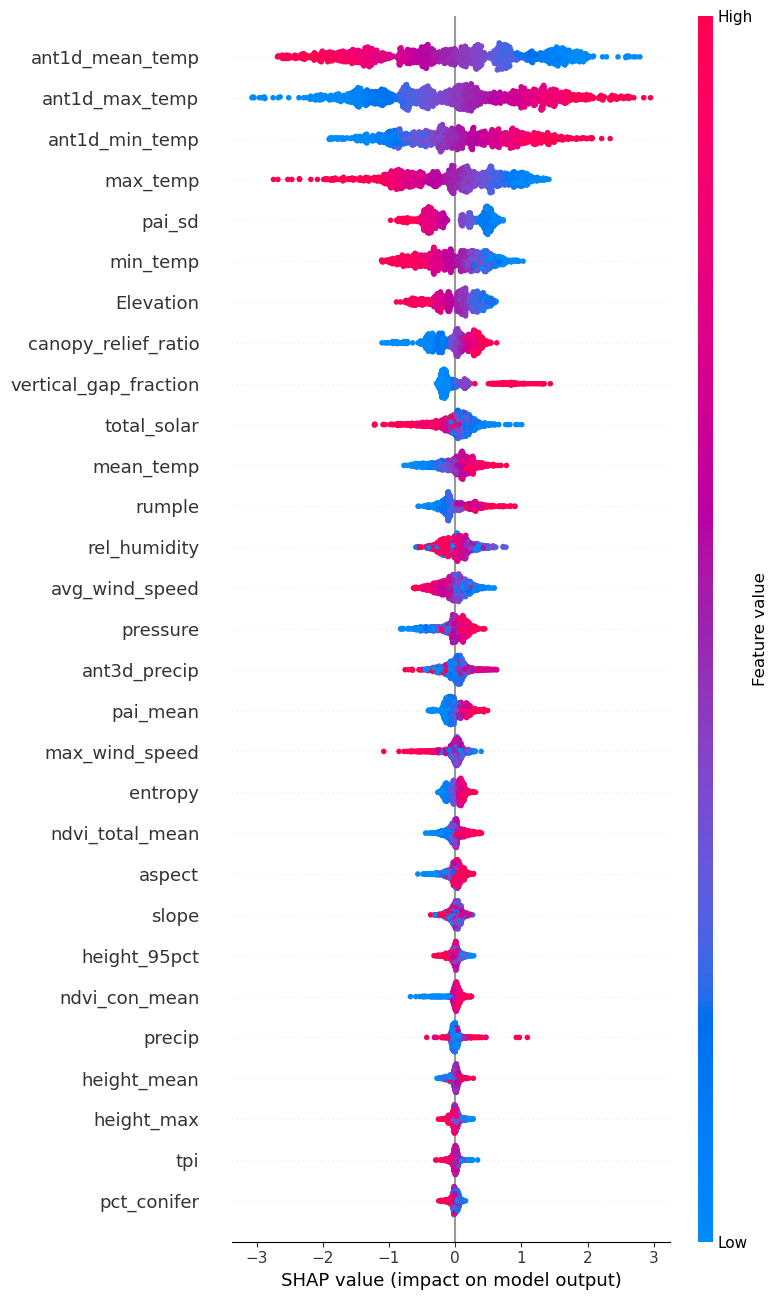

C:\Users\jrladue\AppData\Local\Temp\ipykernel_41968\2698367264.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full_forest, X_forest)


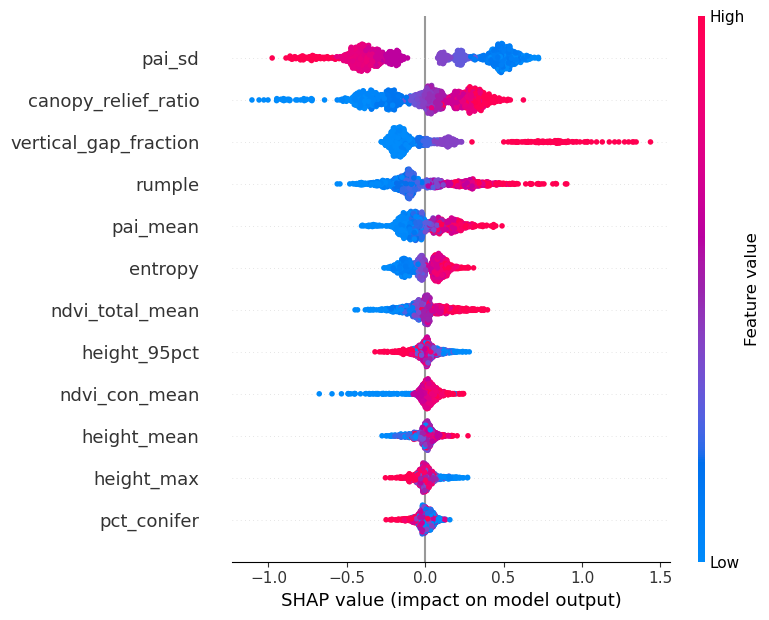

In [20]:
shap.summary_plot(shap_values_full, X_ablat, max_display = 35)
shap.summary_plot(shap_values_full_forest, X_forest)

In [ ]:
explanation = explainer(X_ablat_fit)

PermutationExplainer explainer: 1214it [03:34,  5.38it/s]                          


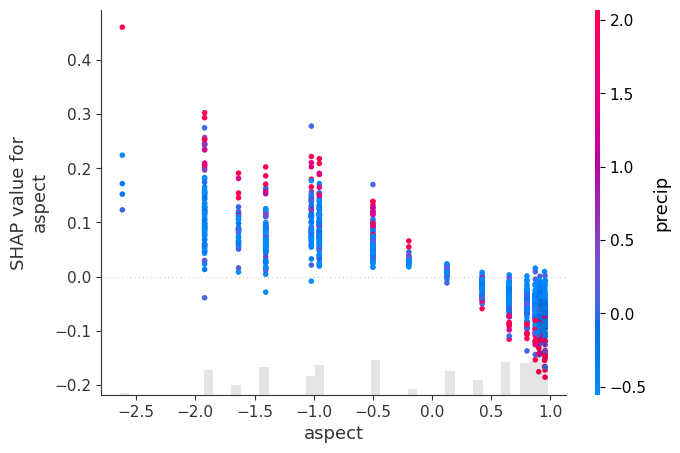

In [110]:
shap.plots.scatter(explanation[:,1], color = explanation)

(array([ 20.,  57., 339., 660., 130.,  13.,   0.,   0.,   0.,   2.]),
 array([-3.77872294, -2.60894177, -1.4391606 , -0.26937942,  0.90040175,
         2.07018292,  3.23996409,  4.40974527,  5.57952644,  6.74930761,
         7.91908879]),
 <BarContainer object of 10 artists>)

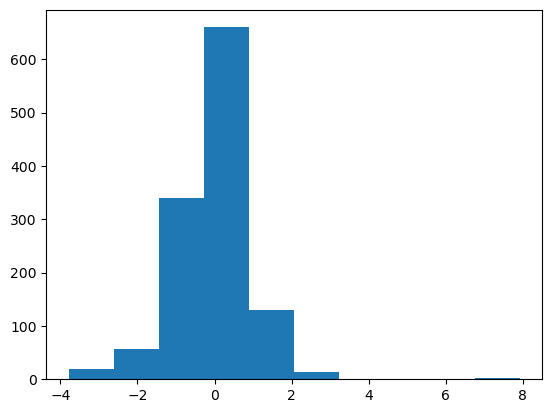

In [112]:
plt.hist(y_ablat_fit)